In [6]:
import numpy as np
import pickle
import cv2

import matplotlib.pyplot as plt

In [7]:
H, W = 512, 512

In [8]:
def plot_gradients(image, theta, stride):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")

    H, W = image.shape

    # compute arrow positions (center of each orientation block)
    theta = np.mod(theta, 2 * np.pi)
    ys, xs = np.mgrid[0:H:stride, 0:W:stride]
    U = np.cos(theta[::stride, ::stride])
    V = np.sin(theta[::stride, ::stride])

    # draw quiver with small width and pivot in the middle so arrows don't fill blocks
    plt.quiver(
        xs,
        ys,
        U,
        V,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=0.07,
        width=0.003,
        headaxislength=0,
        headlength=0,
        headwidth=0,
    )

    # plt.gca().invert_yaxis()
    plt.title("Blockwise Dominant Ridge Orientation")
    plt.axis("off")

[[  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]
 ...
 [  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]
 [  0   1   2 ... 509 510 511]]
[[  0   0   0 ...   0   0   0]
 [  1   1   1 ...   1   1   1]
 [  2   2   2 ...   2   2   2]
 ...
 [509 509 509 ... 509 509 509]
 [510 510 510 ... 510 510 510]
 [511 511 511 ... 511 511 511]]
[[-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]
 ...
 [-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]
 [-256 -255 -254 ...  253  254  255]]
[[-256 -256 -256 ... -256 -256 -256]
 [-255 -255 -255 ... -255 -255 -255]
 [-254 -254 -254 ... -254 -254 -254]
 ...
 [ 253  253  253 ...  253  253  253]
 [ 254  254  254 ...  254  254  254]
 [ 255  255  255 ...  255  255  255]]


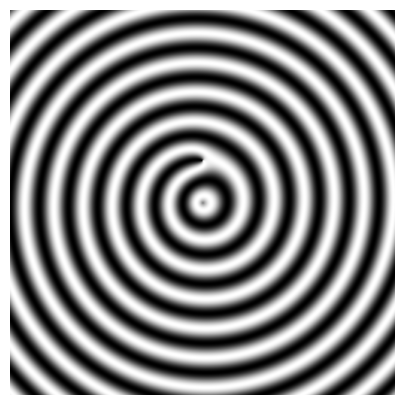

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

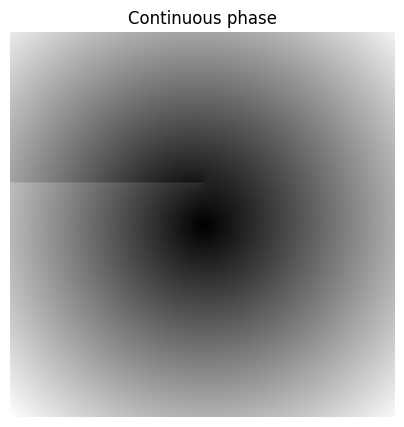

In [9]:
yy, xx = np.mgrid[:H, :W]
cx, cy = W // 2, H // 2
X = xx - cx
Y = yy - cy

def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    for (yy, xx), p in zip(points, polarities):
        out += p * np.arctan2(Y-yy, X-xx)
    return out

print(xx)
print(yy)

print(X)
print(Y)

# radial phase
kappa = 0.16  # controls spacing of rings (ridges)
psi_c = kappa * np.sqrt(X * X + Y * Y)
psi_c = add_spiral_phase(psi_c, points=[(200, 256)], polarities=[+1])

original_phase = psi_c.copy()

# render ridges (dark)
I = 0.5 * (1.0 - np.cos(psi_c))
img = (I * 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Continuous phase")
plt.imshow(psi_c, cmap="gray")
plt.axis("off")

# I_s = 0.5 * (1.0 - np.cos(psi_s))
# img_s = (I_s * 255).astype(np.uint8)
# plt.figure(figsize=(5, 5))
# plt.imshow(img_s, cmap="gray")
# plt.axis("off")
# plt.show()

In [10]:
w = 8  # Block size

Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

Gx2 = Gx * Gx
Gy2 = Gy * Gy
Gxy = Gx * Gy

sum_Gx2 = cv2.boxFilter(Gx2, -1, (w, w), normalize=False)
sum_Gy2 = cv2.boxFilter(Gy2, -1, (w, w), normalize=False)
sum_Gxy = cv2.boxFilter(Gxy, -1, (w, w), normalize=False)

# Vx = sum_Gxy[w // 2 :: w, w // 2 :: w] * 2  # The original paper uses 2 * sum_Gxy
# Vy = sum_Gx2[w // 2 :: w, w // 2 :: w] - sum_Gy2[w // 2 :: w, w // 2 :: w]

Vx = 2 * sum_Gxy
Vy = sum_Gx2 - sum_Gy2

theta = 0.5 * np.arctan2(Vx, Vy)
Tx = np.cos(2 * theta)
Ty = np.sin(2 * theta)

Tprime_x = cv2.GaussianBlur(Tx, (5, 5), 0)
Tprime_y = cv2.GaussianBlur(Ty, (5, 5), 0)

theta_smoothed = 0.5 * np.arctan2(Tprime_y, Tprime_x)

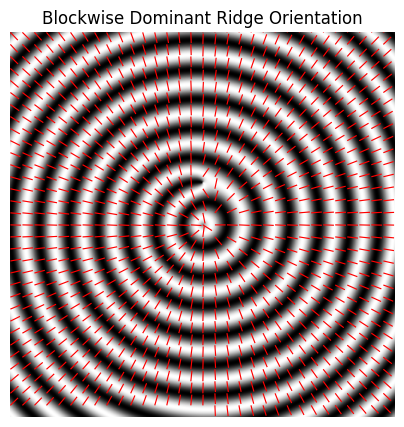

In [11]:
plot_gradients(img, theta_smoothed, stride=16)

In [12]:
# yy, xx  = np.mgrid[:H, :W]
# f = 0.015

# continuous_phase = 2 * np.pi * f * yy
# I = 0.5 * (1.0 - np.cos(continuous_phase))
# print(I.shape)
# img = (I * 255).astype(np.uint8)

# spiral_phase = add_spiral_phase(continuous_phase, points=[(200, 256)], polarities=[+1])

# plt.figure(figsize=(5, 5))
# plt.imshow(continuous_phase, cmap="gray")
# plt.axis("off")
# plt.show()

# plt.figure(figsize=(5, 5))
# plt.imshow(spiral_phase, cmap="gray")
# plt.axis("off")
# plt.show()

# plt.figure(figsize=(5, 5))
# plt.imshow(img, cmap="gray")
# plt.axis("off")
# plt.show()

# spiral_phase = 0.5 * (1.0 - np.cos(spiral_phase))
# img_s = (spiral_phase * 255).astype(np.uint8)
# plt.figure(figsize=(5, 5))
# plt.imshow(img_s, cmap="gray")
# plt.axis("off")
# plt.show()

In [13]:
def ridge_tangent(theta_edge):
    """If you estimated EDGE orientation, convert to RIDGE tangent: θ_ridge = θ_edge + π/2 mod π."""
    return (theta_edge + np.pi / 2.0) % np.pi


def build_v(theta_ridge, freq):
    """Target phase gradient v = ∇ψ = 2π f [cos θ, sin θ]."""
    vx = 2.0 * np.pi * freq * np.cos(theta_ridge)
    vy = 2.0 * np.pi * freq * np.sin(theta_ridge)
    return vx, vy


def div_centered(vx, vy):
    """Centered-difference divergence (periodic stencil; swap for one-sided if desired)."""
    dvx_dx = 0.5 * (np.roll(vx, -1, 1) - np.roll(vx, 1, 1))
    dvy_dy = 0.5 * (np.roll(vy, -1, 0) - np.roll(vy, 1, 0))
    return dvx_dx + dvy_dy


def render_from_phase(psi, dark_ridges=True):
    I = 0.5 * (1.0 - np.cos(psi)) if dark_ridges else 0.5 * (1.0 + np.cos(psi))
    return (np.clip(I, 0, 1) * 255).astype(np.uint8)

In [14]:
def phase_poisson_fft(theta_ridge, freq):
    """
    Solve Δψ = div(2π f [cosθ, sinθ]) with periodic BC via FFT.
    Returns ψ (mean-zero).
    """
    H, W = theta_ridge.shape
    vx, vy = build_v(theta_ridge, freq)
    div_v = div_centered(vx, vy)

    kx = 2 * np.pi * np.fft.fftfreq(W)
    ky = 2 * np.pi * np.fft.fftfreq(H)
    KX, KY = np.meshgrid(kx, ky)
    DEN = -(KX**2 + KY**2)

    DIV = np.fft.fft2(div_v)
    DEN[0, 0] = 1.0  # avoid division by zero at DC
    PSI = DIV / DEN
    PSI[0, 0] = 0.0  # fix arbitrary constant (mean-zero ψ)
    psi = np.real(np.fft.ifft2(PSI))
    return psi

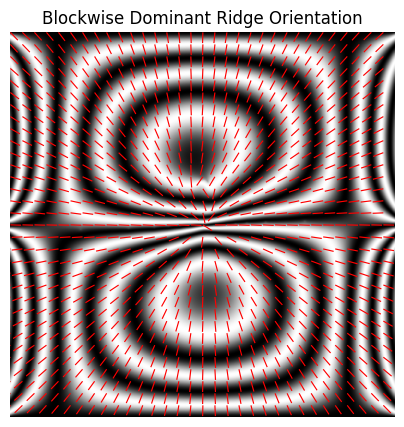

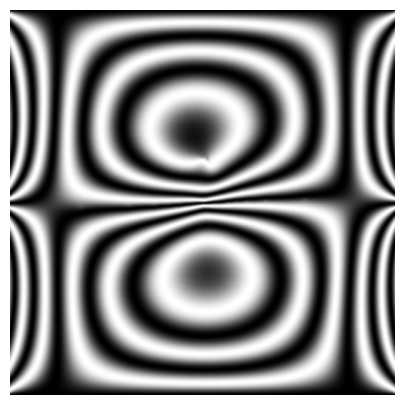

In [15]:
# theta_map = pickle.load(open("theta_smoothed.pkl", "rb"))

# Ensure we have per-pixel orientation and frequency maps at image resolution
C = np.cos(2.0 * theta_smoothed)
S = np.sin(2.0 * theta_smoothed)

C = cv2.resize(C, (W, H), interpolation=cv2.INTER_CUBIC)
S = cv2.resize(S, (W, H), interpolation=cv2.INTER_CUBIC)

# 3) Back to angle, then wrap to [0, π)
theta = 0.5 * np.arctan2(S, C)  # now in (-π/2, π/2]
theta_map = np.mod(theta, np.pi)  # -> [0, π)

freq_map = np.full_like(theta_map, 0.05)

psi_map = phase_poisson_fft(theta_map, freq_map)
ridge_img = render_from_phase(psi_map, dark_ridges=True)

plot_gradients(ridge_img, theta_map, stride=16)

plt.figure(figsize=(5, 5))
plt.imshow(ridge_img, cmap="gray")
plt.axis("off")
plt.show()

## Reconstruct from complex plane

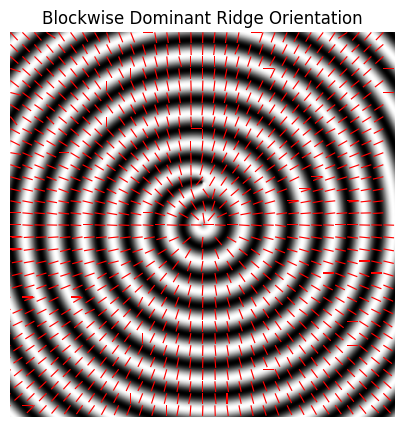

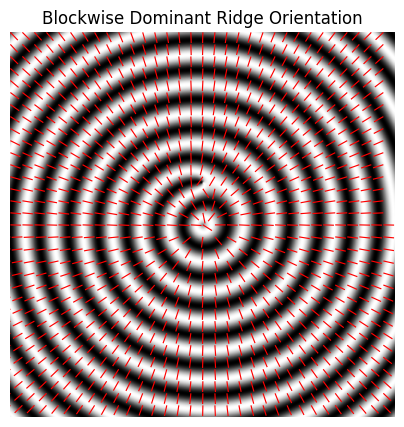

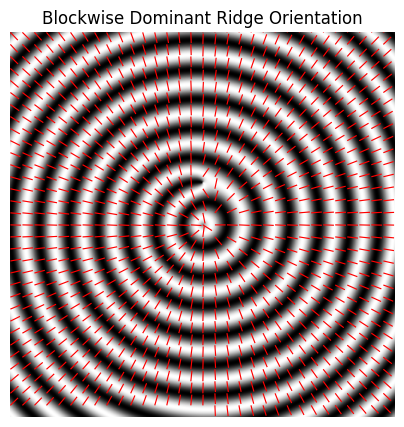

In [16]:
dpsi_dx = np.gradient(img, axis=1)
dpsi_dy = np.gradient(img, axis=0)

theta = np.arctan2(dpsi_dy, dpsi_dx)
theta = np.mod(theta, np.pi)

# phase gradient magnitude → local spatial frequency
# orientation (edge direction, in radians)
plot_gradients(img, theta, stride=16)
plot_gradients(img, theta_map, stride=16)
plot_gradients(img, theta_smoothed, stride=16)

In [17]:
def unwrap_orientation_simple(wrapped_orientation_map):
    M, N = wrapped_orientation_map.shape
    # Initialize unwrapped map with the starting angle
    unwrapped_map = np.copy(wrapped_orientation_map)

    # Define a path (e.g., scanning row-by-row)
    for m in range(M):
        for n in range(N):
            current_wrapped = wrapped_orientation_map[m, n]

            # --- Check Vertical Neighbor (m-1) ---
            if m > 0:
                # The difference between the current wrapped angle and the
                # neighbor's *already unwrapped* angle is used to calculate k.
                prev_unwrapped = unwrapped_map[m - 1, n]
                diff = current_wrapped - prev_unwrapped

                # k * pi is the correction factor needed to bring the difference
                # into the range (-pi/2, pi/2), or just ensure continuity.
                k = np.round(diff / np.pi)
                unwrapped_map[m, n] -= k * np.pi

            # --- Check Horizontal Neighbor (n-1) ---
            # NOTE: For a path-dependent method, order is critical. We must use
            # the newly corrected angle for the horizontal check if vertical was done.
            if n > 0:
                prev_unwrapped = unwrapped_map[m, n - 1]
                diff = unwrapped_map[m, n] - prev_unwrapped

                # Re-calculate k based on the difference after the vertical correction
                k = np.round(diff / np.pi)
                unwrapped_map[m, n] -= k * np.pi

    return unwrapped_map

In [18]:
freq_map = np.full_like(theta_map, 0.111)
unwrapped_theta = unwrap_orientation_simple(theta_map)

G_phase = 2 * np.pi * freq_map * np.exp(1j * (unwrapped_theta))

phase_field_complex = ls_phase_reconstruction_complex(G_phase)
reconstructed_img_complex = render_from_phase(phase_field_complex, dark_ridges=True)

plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original image (fingerprint)")
plt.imshow(img, cmap="gray")
plt.axis("off")
s
plt.subplot(1, 2, 2)
plt.title("Reconstruction via LS DCT (complex gradients)")
plt.imshow(reconstructed_img_complex, cmap="gray")
plt.axis("off")
plt.show()

NameError: name 'ls_phase_reconstruction_complex' is not defined

## Original Paper Implementation (flood-fill algorithm)

In [ ]:
import numpy as np
from collections import deque


def phase_integration_feng_jain(
    Gcx_block: np.ndarray, Gcy_block: np.ndarray, block_size=8
) -> np.ndarray:
    H, W = Gcx_block.shape  # Block dimensions (H rows, W columns of blocks)
    I_H, I_W = H * block_size, W * block_size  # Image dimensions

    P = np.full((H, W), np.nan)  # Phase offset P(m,n): initialize as unknown
    reconstructed_mask = np.zeros((H, W), dtype=bool)

    # Initialize the final phase image
    Psi_C = np.zeros((I_H, I_W), dtype=float)

    # 1. Initialize Queue and Starting Block (Flood-Fill Setup)
    m_start, n_start = 0, 0
    if Gcx_block.size == 0:
        return Psi_C

    queue = deque([(m_start, n_start)])
    P[m_start, n_start] = 0.0  # Assume phase offset of the first block is 0 [cite: 354]
    reconstructed_mask[m_start, n_start] = True

    # Pre-calculate coordinate matrices for the block model (Eq. 14)
    # X_local and Y_local are 8x8 matrices of pixel coordinates within a block (0 to 7)
    X_local, Y_local = np.meshgrid(np.arange(block_size), np.arange(block_size))

    # 2. Iterative Phase Reconstruction (Flood-Fill)
    while queue:
        m_curr, n_curr = queue.popleft()  # Current (reconstructed) block coordinates

        # Iterate over 4-connected neighbors
        for dm, dn in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            m_neigh, n_neigh = m_curr + dm, n_curr + dn

            # Check bounds and if the neighbor is in the foreground/unreconstructed
            if (
                0 <= m_neigh < H
                and 0 <= n_neigh < W
                and not reconstructed_mask[m_neigh, n_neigh]
            ):

                # --- A. Define Border and Estimate Phase Offset P(m_neigh, n_neigh) ---

                phase_candidates = (
                    []
                )  # List to hold phase offsets (psi) estimated at border pixels

                # Current block's phase P_curr
                P_curr = P[m_curr, n_curr]

                # Determine border coordinates and fixed axis (x= or y=)
                if dm == 0 and dn == 1:  # Right neighbor (Border: x = n_curr*8 + 7)
                    x_pix = n_curr * block_size + block_size - 1
                    y_range = np.arange(m_curr * block_size, (m_curr + 1) * block_size)
                    fixed_axis = "x"
                elif dm == 0 and dn == -1:  # Left neighbor (Border: x = n_curr*8)
                    x_pix = n_curr * block_size
                    y_range = np.arange(m_curr * block_size, (m_curr + 1) * block_size)
                    fixed_axis = "x"
                elif dm == 1 and dn == 0:  # Down neighbor (Border: y = m_curr*8 + 7)
                    y_pix = m_curr * block_size + block_size - 1
                    x_range = np.arange(n_curr * block_size, (n_curr + 1) * block_size)
                    fixed_axis = "y"
                elif dm == -1 and dn == 0:  # Up neighbor (Border: y = m_curr*8)
                    y_pix = m_curr * block_size
                    x_range = np.arange(n_curr * block_size, (n_curr + 1) * block_size)
                    fixed_axis = "y"
                else:
                    continue  # Should not happen

                # Iterate over border pixels to collect phase offsets
                if fixed_axis == "x":
                    for y in y_range:
                        x = x_pix
                        # Calculate phase of current block at (x, y) [cite: 362]
                        psi_curr = (
                            Gcx_block[m_curr, n_curr] * x
                            + Gcy_block[m_curr, n_curr] * y
                            + P_curr
                        )

                        # Calculate the part of the neighbor's phase model NOT including P_neigh
                        # Note: Gcx/Gcy for the neighbor is used here [cite: 362]
                        gradient_contribution_neigh = (
                            Gcx_block[m_neigh, n_neigh] * x
                            + Gcy_block[m_neigh, n_neigh] * y
                        )

                        # The phase offset candidate is: P_neigh = psi_curr - gradient_contribution_neigh
                        phase_candidates.append(psi_curr - gradient_contribution_neigh)
                elif fixed_axis == "y":
                    for x in x_range:
                        y = y_pix
                        psi_curr = (
                            Gcx_block[m_curr, n_curr] * x
                            + Gcy_block[m_curr, n_curr] * y
                            + P_curr
                        )
                        gradient_contribution_neigh = (
                            Gcx_block[m_neigh, n_neigh] * x
                            + Gcy_block[m_neigh, n_neigh] * y
                        )
                        phase_candidates.append(psi_curr - gradient_contribution_neigh)

                # Convert phase offsets to complex numbers, average, and convert back
                complex_candidates = np.exp(1j * np.array(phase_candidates))
                complex_mean = np.mean(complex_candidates)
                P_new = np.arctan2(complex_mean.imag, complex_mean.real)

                # --- B. Update and Propagate ---
                P[m_neigh, n_neigh] = P_new
                reconstructed_mask[m_neigh, n_neigh] = True
                queue.append((m_neigh, n_neigh))

    # 3. Generate Final Continuous Phase Image Psi_C (Pixel-Level Fill)
    for m in range(H):
        for n in range(W):
            if reconstructed_mask[m, n]:
                # Get block's model parameters
                Gcx = Gcx_block[m, n]
                Gcy = Gcy_block[m, n]
                P_offset = P[m, n]

                # Calculate pixel coordinates (global) for the 8x8 block
                x_start, y_start = n * block_size, m * block_size
                X_global = X_local + x_start
                Y_global = Y_local + y_start

                # Apply the piecewise planar model: Psi_C = Gcx*x + Gcy*y + P(m,n)
                Psi_C[
                    y_start : y_start + block_size, x_start : x_start + block_size
                ] = (Gcx * X_global + Gcy * Y_global + P_offset)

    return Psi_C

(512, 512) (512, 512)


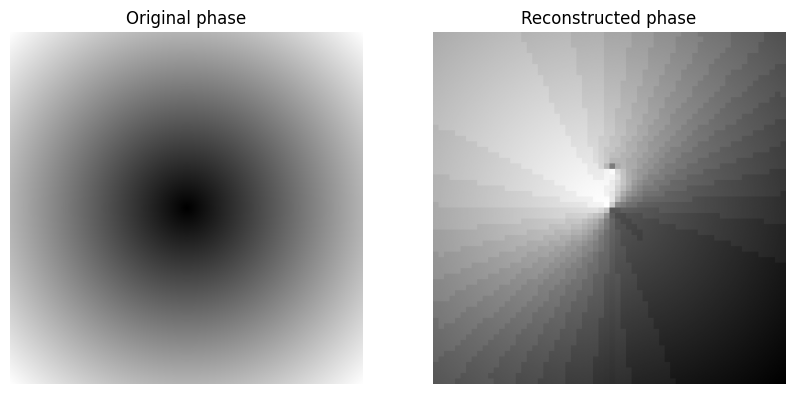

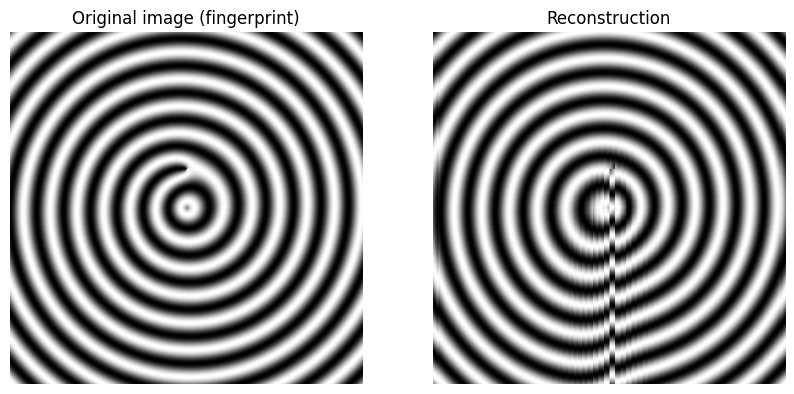

In [ ]:
freq_map = np.full_like(theta_map, 0.0247)
unwrapped_theta = unwrap_orientation_simple(theta_map)
Gx = 2 * np.pi * freq_map * np.cos(unwrapped_theta)
Gy = 2 * np.pi * freq_map * np.sin(unwrapped_theta)

Gcx_block = cv2.resize(Gx, (W // 8, H // 8), interpolation=cv2.INTER_CUBIC)
Gcy_block = cv2.resize(Gy, (W // 8, H // 8), interpolation=cv2.INTER_CUBIC)

phase_field_feng_jain = phase_integration_feng_jain(
    Gcx_block=Gcx_block, Gcy_block=Gcy_block, block_size=8
)
phase_field_feng_jain_render = render_from_phase(phase_field_feng_jain, dark_ridges=True)

print(img.shape, phase_field_feng_jain_render.shape)


plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original phase")
plt.imshow(original_phase, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed phase")
plt.imshow(phase_field_feng_jain, cmap="gray")
plt.axis("off")
plt.show()


plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original image (fingerprint)")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstruction")
plt.imshow(phase_field_feng_jain_render, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import pickle

fprint_theta_map = pickle.load(open("theta_smoothed.pkl", "rb"))

fprint_theta_map_cos = np.cos(2.0 * fprint_theta_map)
fprint_theta_map_sin = np.sin(2.0 * fprint_theta_map)

# fprint_theta_map_cos = cv2.resize(fprint_theta_map_cos, (W // 8, H // 8), interpolation=cv2.INTER_CUBIC)
# fprint_theta_map_sin = cv2.resize(fprint_theta_map_sin, (W // 8, H // 8), interpolation=cv2.INTER_CUBIC)

fprint_theta_map = 0.5 * np.arctan2(fprint_theta_map_sin, fprint_theta_map_cos)
fprint_theta_map = np.mod(fprint_theta_map, np.pi)

freq_map = np.full_like(fprint_theta_map, 0.05)
theta_reconstruction = unwrap_orientation_simple(fprint_theta_map)

theta_x =  2 * np.pi * freq_map * np.cos(theta_reconstruction)
theta_y = 2 * np.pi * freq_map * np.sin(theta_reconstruction)

theta_phase_field = phase_integration_feng_jain(
    Gcx_block=theta_x, Gcy_block=theta_y, block_size=8
)
theta_phase_field_render = render_from_phase(theta_phase_field, dark_ridges=True)

print(theta_reconstruction.shape)
print(theta_phase_field_render.shape)

if theta_reconstruction.shape != theta_phase_field_render.shape:
    w, h = theta_phase_field_render.shape

    theta_reconstruction_C = np.cos(2.0 * theta_reconstruction)
    theta_reconstruction_S = np.sin(2.0 * theta_reconstruction)

    theta_reconstruction_C = cv2.resize(theta_reconstruction_C, (w, h), interpolation=cv2.INTER_CUBIC)
    theta_reconstruction_S = cv2.resize(theta_reconstruction_S, (w, h), interpolation=cv2.INTER_CUBIC)

    resized_theta_reconstruction = 0.5 * np.arctan2(theta_reconstruction_S, theta_reconstruction_C)
    resized_theta_reconstruction = np.mod(resized_theta_reconstruction, np.pi)

    print(resized_theta_reconstruction.shape)
    print(theta_phase_field_render.shape)
    
    plot_gradients(theta_phase_field_render, resized_theta_reconstruction, stride=16)
else: 
    plot_gradients(theta_phase_field_render, theta_reconstruction, stride=16)

plt.figure(figsize=(5, 5))
plt.title("Phase image")
plt.imshow(theta_phase_field, cmap="gray")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Reconstruction")
plt.imshow(theta_phase_field_render, cmap="gray")
plt.axis("off")
plt.show()